# Lesson 159 · Pre-training objectives

Standalone **synthetic mechanism** lab, not a BART or paper reproduction. PROVIDED cells contain the complete codec, graph and trainer; three TODOs affect actual training; CHECK cells reject incorrect behavior; EXIT asks for a vision brief. One CPU thread, 120-second training cap, $0 cloud. Paper target NOT_RUN. Course links may be unavailable before publication; the experiment itself needs no repository files.

## 1 · From a reusable pipeline to reusable knowledge

**Reading route.** Define the hidden identity → trace row and graph computation → place the loss → follow gradients → design a transfer test.

**Your win:** specify one masked reconstruction objective and explain what evidence would turn useful pre-training into a credible transfer claim. Read for about 25 minutes; allow 45–60 minutes for the notebook and one-page brief.

[L158](https://avistian.github.io/relational/lessons/0158-year-4-synthesis.html) left us with reproducible task-specific evidence, an unresolved broad advantage, and missing human-effort observations. Reusing its training script saves engineering work. It does not show that the fitted weights know how to handle a different database. This is the gap that motivates today's question: **could one representation support many later tasks?**

A **representation** is the vector a model computes from its input. **Pre-training** learns such vectors before the intended downstream task. **Adaptation** changes or conditions a pre-trained model using information from the new task. **Transfer** is the measured usefulness of that prior learning on a different task or population. A lower pre-training loss alone does not measure transfer.

**Primary reading:** [Vogel, Hilprecht and Binnig (2023), Sections 2–4](https://arxiv.org/html/2305.15321v1). The earlier curriculum incorrectly called this Zahradník's paper. Read this historical proposal alongside [L147's research map](https://avistian.github.io/relational/lessons/0147-next-generation-architectures.html), then return to its wider agenda in L162. L160's Year 4 exit requirements still apply; this preview does not clear the missing portfolio evidence.

## 2 · Invent a target without inventing a label

> **In plain terms.** Hide something the database already contains. Ask the model to recover it from the information you deliberately leave available.

This is **self-supervision**: observed data supplies the training target. It still needs a strict information policy. A **mask** replaces selected input content with a special marker; the original content is retained separately for scoring.

**Worked example.** Four rows serialize the same table name, `Moons`. We hide the table name in row 0. If rows 1–3 still say `Moons`, a graph can copy the answer. This is not the task “recover a hidden table name.” It is a different, easier task: “fill one missing serialization from another.” Both can be useful, but only if we name the task accurately.

The unit to hide is a **semantic identity**: one actual table name, column name or cell. A table name repeats in all its rows; a column name repeats too. Two cells that both contain `Earth` are distinct identities. Erasing every equal string would remove legitimate context and silently change the problem.

<figure class="fm-figure">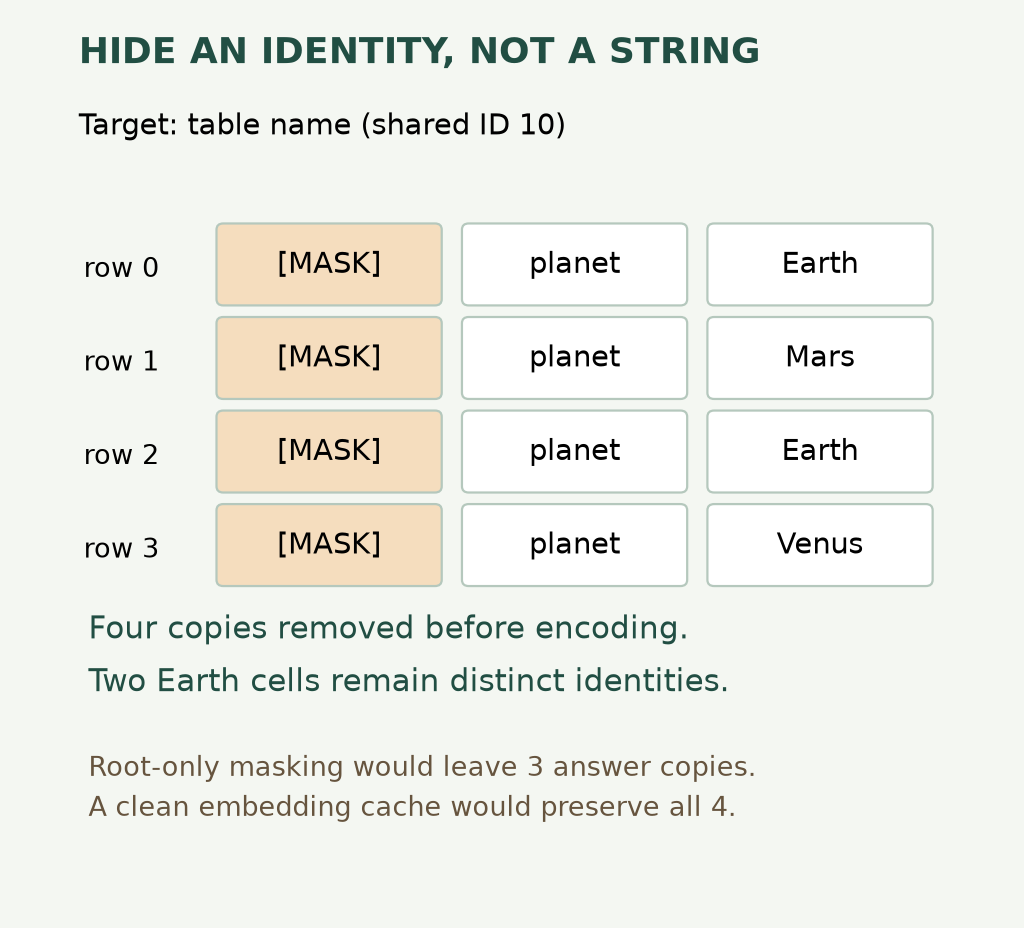<figcaption>A table name is repeated in four row serializations. Global semantic masking removes all copies; equal-valued cells are not the same identity.</figcaption></figure>

**Predict before using the control:** does masking only the root row prevent a graph from seeing a repeated schema name? Switch among targets, masking policies and a clean-embedding cache. The control counts exposed target identities; it does not simulate trained-model accuracy.

Try on paper: table or column target, root-only policy leaves three copies; global policy leaves zero; clean-cache policy retains four. A root-cell target has one identity, so root-only and global both remove it.

**Order matters.** Mask → serialize/encode → propagate. If you encode the clean row first and cache that vector, changing the displayed text later does not remove the answer from the vector. The notebook tests this policy with a counterfactual: change the hidden answer while preserving all other input values; a valid corrupted input stays identical. This test covers direct target copies, not every possible proxy or temporal leak.

**Lab task 1 — `mask_serializations`.** Remove all copies of one identity without mutating the clean targets. An unrelated equal-valued cell must remain visible.

## 3 · Model architecture: language within rows, messages between rows

The paper combines row-wise BART encoding with graph convolution and a text decoder. Its procedure first adapts the language model to table rows, then freezes it while training the graph. It reconstructs cell values, column names and table names. [Sections 2–4](https://arxiv.org/html/2305.15321v1#S2)

**BART** is an encoder–decoder language model: an encoder maps an input token sequence to vectors; a decoder predicts an output token sequence. A **token** is a vocabulary item, often a piece of a word. A **GNN** updates node vectors using neighboring nodes. A **GCN** is a GNN whose graph layer mixes neighboring representations before a learned transformation.

<figure class="fm-figure">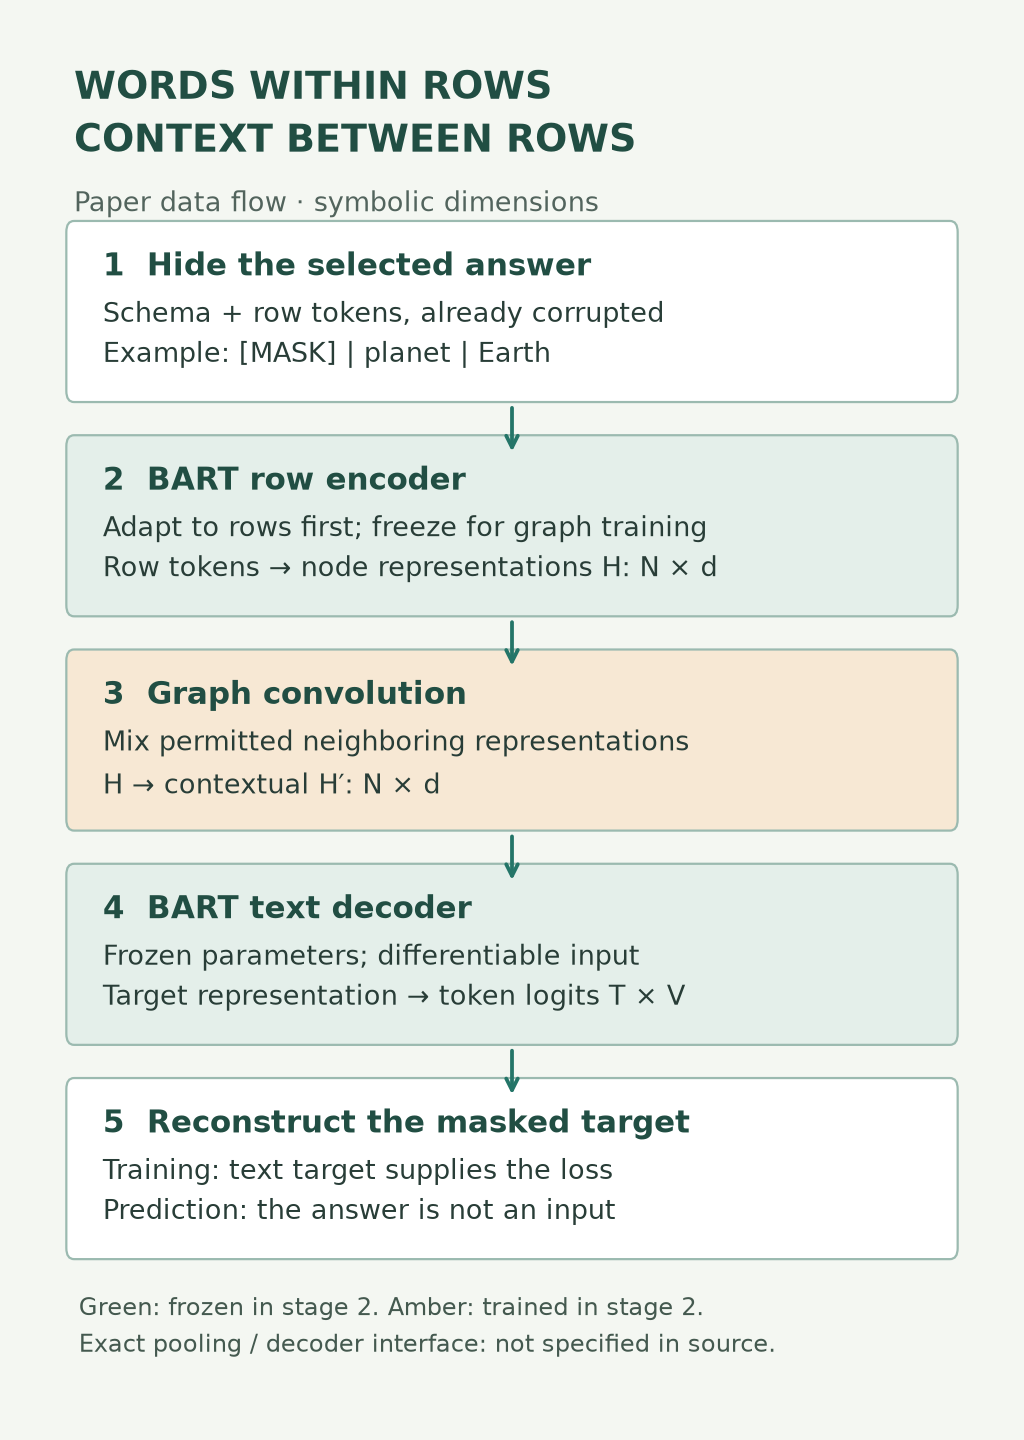<figcaption>Stated paper architecture, not the local binary codec. N is node count, d width, T output length, V vocabulary. Frozen decoder weights still transmit input gradients. The paper leaves the exact representation interface unspecified.</figcaption></figure>

**Trace one target.** Corrupt its input occurrences. Encode the permitted row content. Pass representations along the declared graph edges. Decode the target from its resulting representation. Compare the prediction with the held-out answer. At inference, the true answer is unavailable; the target must not sneak back through preprocessing.

The figure uses symbolic dimensions: `N` nodes, `d` representation width, `T` output tokens, `V` vocabulary size. The paper does not specify enough detail to reconstruct its exact pooling and decoder interface. The diagram shows the stated data flow, not an invented implementation contract. Row-wise encoding helps with many rows; a single very wide row can still exceed the encoder's token limit.

### The executable model in this notebook

The local experiment is a smaller, explicitly different computation:

`4 rows × 6 tokens → 4 × 16 row vectors → 4 × 16 contextual vectors → 3 × 2 logits at row 0`.

A **codec** is the encoder and decoder considered together. **Mean pooling** averages the token vectors to obtain one vector per row. A **head** converts a representation into scores for one target.

A **logit** is a score before normalization into probabilities. We use three binary heads, one per target level. The selected head predicts class 0 or 1; it does not generate text. Our mean-pooled embedding codec is not BART. Every table is a separate four-node complete graph, with self edges; the experiment does not reconstruct the paper's graph design.

For this local graph, every normalized adjacency entry is `1/4`. Thus each row receives the mean of four vectors. With `H` the row vectors, `W` a learned matrix and `b` a bias:

`H′ = tanh((A_normalized H) W + b)`.

`A_normalized` is the 4×4 matrix of averaging weights. Multiplying it by the 4×16 matrix `H` produces four 16-number neighborhood means. `W` is a learned 16×16 transformation; `b` adds one learned offset per coordinate. `tanh` squashes each resulting number into `(−1,1)`. The output `H′` therefore still has shape 4×16.

**One-coordinate trace of the local graph layer.** For illustration, use row representations `[.1, .3, .5, .7]`, scalar weight 2 and bias 0. Every row receives the same complete-graph mean `.4`, then outputs `tanh(.4 × 2) ≈ .664`:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:3px"><thead><tr><th>Row</th><th>Input</th><th>Neighborhood mean</th><th>Output</th></tr></thead><tbody><tr><td>0</td><td>.1</td><td>.4</td><td>.664</td></tr><tr><td>1</td><td>.3</td><td>.4</td><td>.664</td></tr><tr><td>2</td><td>.5</td><td>.4</td><td>.664</td></tr><tr><td>3</td><td>.7</td><td>.4</td><td>.664</td></tr></tbody></table>

This layer discards within-table row differences because all adjacency rows are identical. Reading row 0 afterward does not restore its original identity. This is a property of this deliberately simple local graph, not a claim about the paper's unspecified full interface. **Try it:** change only the last input to .9. **Check:** all four means become .45 and all outputs become `tanh(.9) ≈ .716`. Permuting the four original inputs instead leaves every output unchanged.

The notebook exposes the embedding, encoder, graph operation, decoder, optimizer, checkpoint selection and evaluation. It never hides a model import behind “run this cell.”

> **Scope check.** This is a **Tier C** experiment: a synthetic mechanism laboratory, the course’s label for testing an idea on deliberately constructed small data. It is neither a trained foundation model nor an implementation of BART. The published target remains separately recorded as `NOT_RUN`.

## 4 · Put the loss exactly where the question is

> **In plain terms.** Reward the model for recovering the hidden answer. Do not dilute that signal by rewarding it for repeating fields we left visible.

**Worked example.** Suppose the correct hidden class gets probability 0.75. Its cross-entropy is `−log(0.75) ≈ 0.288` nats, where a nat is a unit based on natural logarithms. Another visible field has a poor prediction. It is not a target of this example, so it contributes nothing to this objective.

For selected targets `S`, the classification objective is:

`L = (1 / |S|) Σ_(i in S) −log p_i(correct class)`.

The local code uses `logsumexp(logits) − correct_logit`, a stable way to compute this without taking the logarithm of rounded probabilities. An empty `S` is an invalid example, not a zero-loss success. The paper's text decoder predicts token sequences; our binary-head loss illustrates target selection but is a different metric and output space.

**Lab task 2 — `masked_cross_entropy`.** Average only over the boolean target mask. CHECK verifies the worked probability and zero gradient for an unselected field. Your implementation drives every actual training update below.

## 5 · Frozen weights can still carry gradients

**Freeze** means exclude parameters from learning. **Detach** means sever the computational path used to differentiate an earlier value. These operations have different consequences.

**Worked example.** A frozen scalar decoder has weight `w=2`. The graph supplies `h=0.4`, so the logit is `z=0.8`; the sigmoid probability is approximately 0.690 for target 1. The gradient back to the graph is `dL/dh = w(p−1) ≈ −0.620`. The decoder's weight stays 2, yet the graph receives a learning signal.

<figure class="fm-figure">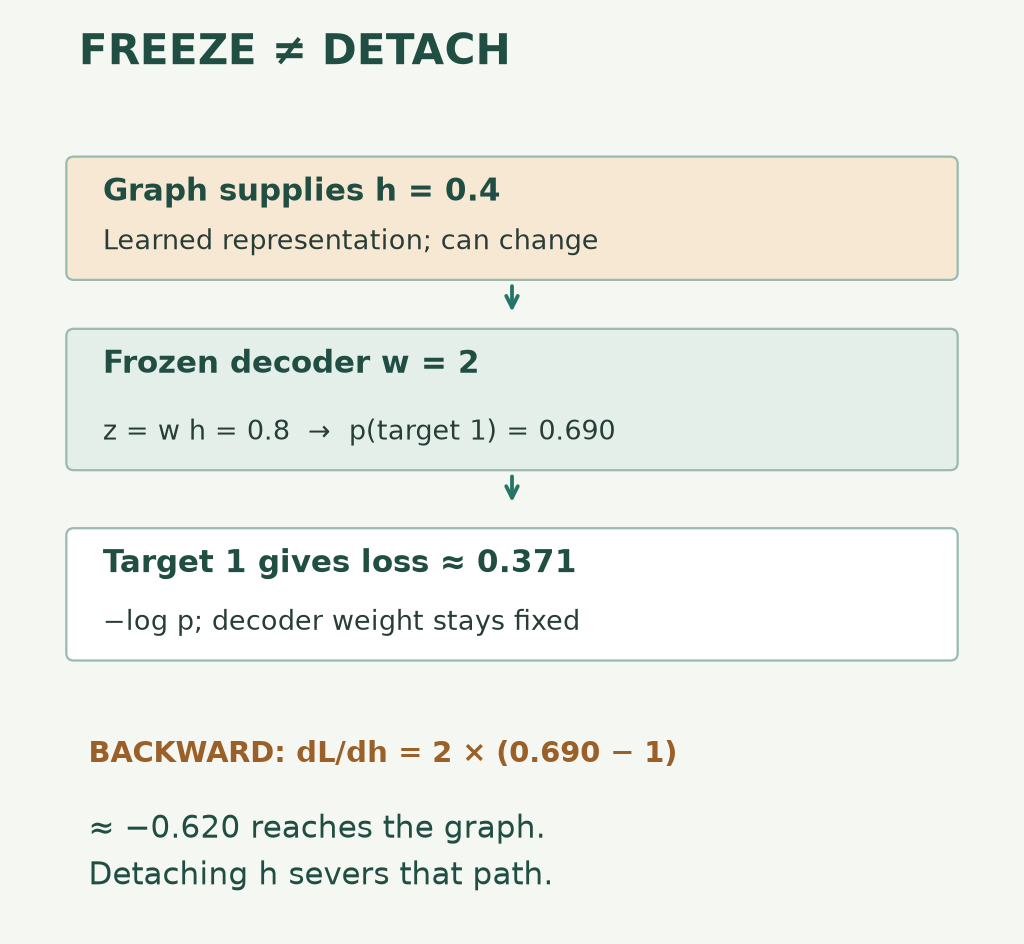<figcaption>One scalar worked example, not a fitted result. A frozen decoder keeps w fixed while passing a nonzero gradient into the graph.</figcaption></figure>

Change h to 0: p=0.5 and the graph gradient is −1 with w=2. Freeze w: the graph gradient remains. Detach h: the graph gradient is absent.

Keep the decoder frozen, then sever the decoder's input path. The prediction is unchanged, but graph learning loses its gradient. In PyTorch, setting decoder parameters to `requires_grad_(False)` preserves input differentiation. Wrapping the whole decoder call in `torch.no_grad()` does not.

**Lab task 3 — `freeze_codec`.** Disable updates to codec parameters and clear old gradients. Leave ordinary forward computation intact. CHECK asks whether an input requiring gradients still receives them. The real trainer then hashes the selected codec before and after graph training and checks that it remains unchanged.

## 6 · Separate the published result, local result and transfer claim

Predict first: does better single-table reconstruction prove transfer to an unseen database? Write the missing evaluation.

**Published evidence.** Table 1 uses 10,000 tables per corpus, a 70/20/10 split, validation-selected checkpoints and three-run means. On wikiTables, row baseline versus graph accuracy is 20.75→46.15% for missing values, 66.88→83.91% for column names, and 36.99→37.85% for table names. These single-table experiments do not establish transfer to unseen multi-table databases. [Section 4, Table 1](https://arxiv.org/html/2305.15321v1#S4)

**Local evidence.** The notebook creates 120 four-row tables, splitting whole tables into 84 train, 24 validation and 12 test. A table supplies three target examples. Seeds 0/1/2 each train the row codec for 80 updates, select a validation checkpoint, freeze it, then train the graph for 80 updates. Test is accessed after both selections. Each arm sees the same corruptions; graph training adds both context and optimization work.

Synthetic mechanism only; percentages below are not paper scores.
| Task | Row mean ± seed SD | Graph mean ± seed SD |
|---|---:|---:|
| Table name | 75.00 ± 0.00% | 83.33 ± 0.00% |
| Column name | 75.00 ± 0.00% | 91.67 ± 0.00% |
| Cell value | 66.67 ± 0.00% | 100.00 ± 0.00% |

All three seeds make the same number of correct predictions here. The zero seed SD is conditional on this tiny fixed generator and split; it is not zero uncertainty about other tables. There are only 12 test targets per task per seed. Neighboring cells intentionally share the target cell's class, while independent noisy cues help reconstruct schema names. The synthetic design therefore supplies strong contextual redundancy. It cannot tell us how often that signal exists in real databases or whether extra training alone explains part of the gain.

> **Scope check.** Author training is complete, with 216 saved predictions independently checked. That is evidence of this declared computation. Paper reproduction is `NOT_RUN`; historical fidelity is `NOT_ESTABLISHED`; cross-database transfer is `NOT_TESTED`. No learner mastery follows from running the solution.

## 7 · What a real transfer test would need

A reconstruction target teaches the model to recover missing information under one corruption policy. A downstream task might instead ask for future churn. Even a perfect reconstruction score need not improve that task.

**Design the boundary before training.** Hold entire databases out of pre-training when claiming unseen-database transfer. State what adaptation may use: labels, rows, schema names and compute. Keep validation and test roles separate. A baseline trained from scratch should receive a declared comparable tuning and adaptation budget. Report pre-training cost separately; amortization over hypothetical future tasks is not observed savings.

**Specify a falsifier.** For example: “On predeclared held-out databases and fixed label budgets, pre-training must improve the chosen downstream metric by a practically meaningful amount versus scratch.” Choose that amount and the uncertainty procedure before test inspection. If the condition fails, retain the negative result. This is a proposed experiment, not an outcome from today's lab.

This extends L158's discipline: a broader claim needs broader evidence. It also explains the Year 5 agenda without treating the foundation-model vision as accomplished.

## 8 · Reproduction audit and your one-page brief

**Named target:** the Table 1 wikiTables row-versus-graph comparison, all three tasks and three runs. The [protocol audit](https://avistian.github.io/relational/labs/l159-reproduction.md) records what is known and what is missing. Exact table/split identities, a matching released implementation and sufficient training/decoding details were not located. The [source manifest](https://avistian.github.io/relational/labs/sources/l159/manifest.json) pins inspected bytes. Our bounded search is not proof of nonexistence.

The [paper gate](https://avistian.github.io/relational/labs/_paper_l159.py) reports those blockers and exits without training. There is no historical benchmark trainer in this package. Unlocking it requires recovering the recipe, implementing or replaying the actual model, and estimating the complete cost. Your standing $10 ceiling covers all seeds, retries and validation; it does not make an unspecified experiment runnable. This lesson used $0 cloud compute.

Open the [student notebook](https://avistian.github.io/relational/labs/0159-foundation-model-preview.ipynb), or inspect the [executed author solution](https://avistian.github.io/relational/labs/html/0159-foundation-model-preview.html) after attempting the tasks. Use the [quick reference](https://avistian.github.io/relational/reference/foundation-model-preview.html) and [brief template](https://avistian.github.io/relational/labs/l159-vision-brief-template.md).

Write 400–600 words: name the unresolved need; specify one corruption objective; trace the computation and frozen-weight boundary; distinguish the three evidence levels; propose a falsifiable transfer experiment. The rubric scores objective clarity, leakage discipline, computation, evidence scope and feasibility, each 0–2. Aim for 8/10 with no zero after teacher review.

Explain frozen versus detached and the gap between reconstruction and transfer. Ask the teaching agent to review your own explanation.

**Spaced practice:** tomorrow recall the three targets and explain frozen versus detached without notes. In a week, diagnose a new duplicated-schema masking bug. Ask the teaching agent any follow-up questions and submit your brief for review. Passing CHECK cells leaves the written defense pending. Carry that distinction into [Lesson 160](https://avistian.github.io/relational/lessons/0160-year-4-exit-exam.html): a correct reconstruction exercise cannot replace missing portfolio experiments.


In [1]:
# PROVIDED · Python 3.10+, PyTorch. Validated with torch 2.13.0+cpu.
# No downloads or cloud dispatch. In a new environment install a CPU PyTorch
# build first; the recorded result is tied to the validated version.
import copy,hashlib,json,math,time
from pathlib import Path
import torch
from torch import nn
torch.set_num_threads(1)
print('PyTorch',torch.__version__)


PyTorch 2.13.0+cpu


## TODO · mask_serializations

**Goal:** Remove all copies of one semantic identity before encoding.

**Why:** this function controls the real experiment, so a mistake changes what the model learns.

**Contract:** Return a new tensor; MASK=0. Require equal 2D shapes, a nonnegative target and at least one match. Do not remove unrelated equal values.

In [2]:
def mask_serializations(tokens, identities, target):
    """Remove every serialization of one semantic identity, leaving targets intact."""
    if tokens.shape != identities.shape or tokens.ndim != 2:
        raise ValueError('Expected equally shaped row-by-token tensors')
    hidden = identities == target
    if target < 0 or not bool(hidden.any()):
        raise ValueError('Unknown semantic target')
    result = tokens.clone()
    result[hidden] = 0  # 0 is the dedicated MASK token, never a target class.
    return result

In [3]:
# CHECK
x=torch.tensor([[2,4,6],[2,4,7]]);ids=torch.tensor([[10,20,30],[10,20,31]])
assert mask_serializations(x,ids,20).tolist()==[[2,0,6],[2,0,7]]
assert x[0,1].item()==4
print('CHECK: schema copies removed; clean input preserved')

CHECK: schema copies removed; clean input preserved


## TODO · masked_cross_entropy

**Goal:** Score only the selected prediction targets.

**Why:** this function controls the real experiment, so a mistake changes what the model learns.

**Contract:** Logits shape [N,3,2]; labels and boolean mask [N,3]. Reject shape mismatch or an empty selection. Return mean negative log-probability of selected true classes.

In [4]:
def masked_cross_entropy(logits, labels, selected):
    """Mean classification loss over explicitly selected targets, not all fields."""
    if logits.shape[:-1] != labels.shape or labels.shape != selected.shape:
        raise ValueError('Target and selection shapes must match logits')
    if selected.dtype != torch.bool or not bool(selected.any()):
        raise ValueError('Select at least one target with a boolean mask')
    scores = logits[selected]
    truth = labels[selected]
    return (torch.logsumexp(scores, dim=-1) - scores.gather(1, truth[:, None]).squeeze(1)).mean()

In [5]:
# CHECK
z=torch.tensor([[[0.,math.log(3.)],[10.,-10.]]],requires_grad=True)
y=torch.tensor([[1,1]]);m=torch.tensor([[True,False]])
loss=masked_cross_entropy(z,y,m);assert abs(float(loss.detach())+math.log(.75))<1e-6
loss.backward();assert z.grad[0,1].abs().sum()==0
print('CHECK: selected loss≈0.288; unselected gradient0')

CHECK: selected loss≈0.288; unselected gradient0


## TODO · freeze_codec

**Goal:** Fix the codec weights while keeping its input differentiable.

**Why:** this function controls the real experiment, so a mistake changes what the model learns.

**Contract:** Operate on every parameter, clearing stale gradients; return value is not used. Your function starts stage 2 of the actual training below.

In [6]:
def freeze_codec(codec):
    """Freeze parameters, not the function: the decoder must differentiate its input."""
    codec.eval()
    for parameter in codec.parameters():
        parameter.requires_grad_(False)
        parameter.grad = None

In [7]:
# CHECK
codec_check=nn.Linear(2,2);freeze_codec(codec_check)
h=torch.ones(1,2,requires_grad=True);codec_check(h).sum().backward()
assert h.grad is not None and all(not p.requires_grad for p in codec_check.parameters())
print('CHECK: frozen parameters preserve input differentiation')

CHECK: frozen parameters preserve input differentiation


## PROVIDED · All neural layers

The paper uses BART and a graph convolution. Here the deliberately smaller binary codec uses token-embedding means; the graph mixes the four rows with normalized adjacency 1/4. Read both forward paths.

In [8]:
class RowCodec(nn.Module):
    """Embedding mean -> nonlinear row representation -> three binary heads."""
    def __init__(self, width=16):
        super().__init__()
        self.embedding = nn.Embedding(14, width)
        self.encoder = nn.Linear(width, width)
        self.decoder = nn.Linear(width, 6)

    def encode(self, tokens):
        return torch.tanh(self.encoder(self.embedding(tokens).mean(dim=-2)))

    def decode(self, hidden):
        return self.decoder(hidden).reshape(*hidden.shape[:-1], 3, 2)

In [9]:
class TableGraph(nn.Module):
    """One GCN-style layer over a four-row complete graph, including self edges."""
    def __init__(self, width=16):
        super().__init__()
        self.weight = nn.Parameter(torch.eye(width))
        self.bias = nn.Parameter(torch.zeros(width))

    def forward(self, hidden):
        n = hidden.shape[-2]
        adjacency = torch.ones(n, n, dtype=hidden.dtype, device=hidden.device) / n
        return torch.tanh(adjacency @ hidden @ self.weight + self.bias)

## PROVIDED · Complete synthetic data and split

The generator creates independent tables and splits entire tables. Cell values repeat by construction; context cues are noisy. The masked semantic identity, not string equality, defines the information policy.

In [10]:
def make_examples(split_seed=159):
    """Split entire synthetic tables; never connect separate train/val/test tables.

    Each level has an independent binary value. Schema tokens repeat across rows;
    a cell's identity is per row even when its value happens to equal another cell.
    Noisy context cues agree with each target 70% of the time. Other observed
    cells share the table's cell class by construction: an intentionally strong
    contextual signal, not a realistic database or a transfer benchmark.
    """
    generator = torch.Generator().manual_seed(split_seed)
    examples = []
    order = torch.randperm(120, generator=generator).tolist()
    assignment = {table: ('train' if i < 84 else 'val' if i < 108 else 'test')
                  for i, table in enumerate(order)}
    for table in range(120):
        labels = torch.randint(0, 2, (3,), generator=generator)
        cues = labels.repeat(4, 1) ^ (torch.rand(4, 3, generator=generator) > .7).long()
        clean = torch.cat((labels.repeat(4, 1) + torch.tensor([2, 4, 6]),
                           cues + torch.tensor([8, 10, 12])), dim=1)
        identities = torch.tensor([[10, 20, 30+r, 100+3*r, 101+3*r, 102+3*r] for r in range(4)])
        for task, target in enumerate([10, 20, 30]):
            tokens = mask_serializations(clean, identities, target)
            selected = torch.zeros(3, dtype=torch.bool); selected[task] = True
            examples.append(dict(key=f'table-{table:03d}/task-{task}', table=table,
                                 split=assignment[table], task=task, tokens=tokens,
                                 labels=labels.clone(), selected=selected))
    return examples

In [11]:
def batch(examples, split):
    rows = [row for row in examples if row['split'] == split]
    return (torch.stack([r['tokens'] for r in rows]),
            torch.stack([r['labels'] for r in rows]),
            torch.stack([r['selected'] for r in rows]), rows)

## PROVIDED · Full two-stage trainer

Stage 1 trains row codec; stage 2 trains graph using frozen codec. Both select by validation accuracy; ties keep earliest epoch. Test is read only after both selections. Saved weights, logits and every validation score are returned. The graph receives extra compute; this does not isolate architecture alone.

In [12]:
def accuracy(logits, labels, selected):
    return float((logits.argmax(-1)[selected] == labels[selected]).float().mean())

In [13]:
def fingerprint(state):
    payload = {key: value.detach().cpu().tolist() for key, value in state.items()}
    return hashlib.sha256(json.dumps(payload, sort_keys=True).encode()).hexdigest()

In [14]:
def run_experiment(seeds=(0, 1, 2), epochs=80, max_seconds=120):
    """Complete the declared local lane or raise; never silently reduce its scope."""
    torch.set_num_threads(1)
    start = time.monotonic()
    examples = make_examples()
    train_x, train_y, train_m, _ = batch(examples, 'train')
    val_x, val_y, val_m, _ = batch(examples, 'val')
    test_x, test_y, test_m, test_rows = batch(examples, 'test')
    runs = []
    for seed in seeds:
        torch.manual_seed(seed)
        codec = RowCodec()
        graph = TableGraph()
        histories = {}
        choices = {}
        frozen_before = None
        for stage in ['row', 'graph']:
            model = codec if stage == 'row' else graph
            if stage == 'graph':
                freeze_codec(codec)
                frozen_before = fingerprint(codec.state_dict())
            optimizer = torch.optim.Adam(model.parameters(), lr=.025)
            best_accuracy = -1.0
            best_state = None
            history = []
            for epoch in range(epochs):
                if time.monotonic() - start > max_seconds:
                    raise TimeoutError('INCOMPLETE: local time cap reached; no scope reduction')
                model.train()
                optimizer.zero_grad(set_to_none=True)
                hidden = codec.encode(train_x)
                if stage == 'graph': hidden = graph(hidden)
                logits = codec.decode(hidden[:, 0])
                loss = masked_cross_entropy(logits, train_y, train_m)
                if not bool(torch.isfinite(loss)): raise ValueError('Nonfinite training loss')
                loss.backward()
                if stage == 'graph' and epoch == 0:
                    if graph.weight.grad is None or graph.weight.grad.abs().sum() == 0:
                        raise AssertionError('Frozen decoder did not transmit gradient')
                optimizer.step()
                model.eval()
                with torch.no_grad():
                    hidden = codec.encode(val_x)
                    if stage == 'graph': hidden = graph(hidden)
                    score = accuracy(codec.decode(hidden[:, 0]), val_y, val_m)
                history.append(dict(epoch=epoch, train_loss=float(loss.detach()), val_accuracy=score))
                if score > best_accuracy:  # ties retain the earliest checkpoint
                    best_accuracy = score
                    best_state = copy.deepcopy(model.state_dict())
                    choices[stage] = epoch
            model.load_state_dict(best_state)
            histories[stage] = history
        frozen_after = fingerprint(codec.state_dict())
        if frozen_before != frozen_after: raise AssertionError('Frozen codec changed')
        predictions = []
        # Neither model accesses test until BOTH validation-selected stages are complete.
        with torch.no_grad():
            h = codec.encode(test_x)
            for arm, hidden in [('row', h), ('graph', graph(h))]:
                logits = codec.decode(hidden[:, 0])
                for row, scores in zip(test_rows, logits):
                    task = row['task']
                    predictions.append(dict(key=row['key'], table=row['table'], task=task, arm=arm,
                                            truth=int(row['labels'][task]),
                                            logits=scores[task].tolist(), prediction=int(scores[task].argmax())))
        runs.append(dict(seed=seed, selected_epoch=choices, histories=histories,
                         frozen_before=frozen_before, frozen_after=frozen_after,
                         codec={k:v.tolist() for k,v in codec.state_dict().items()},
                         graph={k:v.tolist() for k,v in graph.state_dict().items()}, predictions=predictions))
    split_tables = {split: sorted({r['table'] for r in examples if r['split']==split})
                    for split in ['train','val','test']}
    return dict(name='L159 synthetic masked-objective mechanism', status='COMPLETE',
                paper_reproduction='NOT_RUN', paper_fidelity='NOT_ESTABLISHED',
                cross_database_transfer='NOT_TESTED', cloud_spend_usd=0,
                config=dict(seeds=list(seeds),split_seed=159,tables=120,rows_per_table=4,
                            tasks=3,epochs=epochs,width=16,optimizer='Adam',lr=.025,
                            selection='maximum validation accuracy; earliest tie',
                            cpu_threads=1,max_seconds=max_seconds),
                splits=split_tables,runs=runs)

In [15]:
def summarize(report):
    lines = ['Synthetic mechanism only; percentages below are not paper scores.',
             '| Task | Row mean ± seed SD | Graph mean ± seed SD |',
             '|---|---:|---:|']
    for task,name in enumerate(['Table name','Column name','Cell value']):
        values = {}
        for arm in ['row','graph']:
            scores=[]
            for run in report['runs']:
                rows=[p for p in run['predictions'] if p['task']==task and p['arm']==arm]
                scores.append(100*sum(p['truth']==p['prediction'] for p in rows)/len(rows))
            mean=sum(scores)/len(scores)
            sd=math.sqrt(sum((x-mean)**2 for x in scores)/(len(scores)-1)) if len(scores)>1 else 0.
            values[arm]=f'{mean:.2f} ± {sd:.2f}%'
        lines.append(f"| {name} | {values['row']} | {values['graph']} |")
    return '\n'.join(lines)

## CHECK · Adversarial contracts
Before fitting, reject partial masking, empty objectives and a severed frozen-decoder path. The target counterfactual below must not alter corrupted inputs.

In [16]:
def check(mask_serializations, masked_cross_entropy, freeze_codec):
    tokens=torch.tensor([[2,4,6],[2,4,7]])
    identities=torch.tensor([[10,20,30],[10,20,31]])
    masked=mask_serializations(tokens,identities,20)
    assert masked.tolist()==[[2,0,6],[2,0,7]], 'Mask every copy of a schema target before encoding'
    assert tokens.tolist()==[[2,4,6],[2,4,7]], 'Do not modify clean targets in place'
    assert mask_serializations(tokens,identities,30).tolist()==[[2,4,0],[2,4,7]], 'Do not erase unrelated cells'
    for bad in [-1,99]:
        try: mask_serializations(tokens,identities,bad)
        except ValueError: pass
        else: raise AssertionError('Unknown target identity must be rejected')
    logits=torch.tensor([[[0.,math.log(3.)],[10.,-10.]]],requires_grad=True)
    loss=masked_cross_entropy(logits,torch.tensor([[1,1]]),torch.tensor([[True,False]]))
    assert abs(float(loss.detach())+math.log(.75))<1e-6, 'Loss must average selected targets only'
    loss.backward();assert torch.equal(logits.grad[0,1],torch.zeros(2)), 'Unselected logits must have zero gradient'
    try: masked_cross_entropy(logits,torch.tensor([[1,1]]),torch.zeros(1,2,dtype=torch.bool))
    except ValueError: pass
    else: raise AssertionError('An empty objective must fail, not yield NaN')
    codec=torch.nn.Linear(2,2)
    for p in codec.parameters():p.grad=torch.ones_like(p)
    freeze_codec(codec)
    assert all(not p.requires_grad and p.grad is None for p in codec.parameters())
    before={k:v.clone() for k,v in codec.state_dict().items()}
    h=torch.tensor([[.2,.3]],requires_grad=True)
    codec(h).square().sum().backward()
    assert h.grad is not None and h.grad.abs().sum()>0, 'Frozen weights must still transmit gradients'
    assert all(torch.equal(before[k],v) for k,v in codec.state_dict().items())
    return 'PASS: masking, selected loss, and frozen differentiable decoder'

In [17]:
print(check(mask_serializations,masked_cross_entropy,freeze_codec))
clean=torch.tensor([[2,4,6],[2,4,7]]);ids=torch.tensor([[10,20,30],[10,20,31]])
changed=clean.clone();changed[ids==20]=5
assert torch.equal(mask_serializations(clean,ids,20),mask_serializations(changed,ids,20))

PASS: masking, selected loss, and frozen differentiable decoder


## Run the complete declared mechanism
Three paired seeds × two 80-update stages. No benchmark download or paid launch. Predict which target benefits from neighboring unmasked cell values, then run. A timeout stops with INCOMPLETE rather than changing scope.

In [18]:
report=run_experiment()
print(summarize(report))
assert len(report['runs'])==3
assert sum(len(r['predictions']) for r in report['runs'])==216
assert all(r['frozen_before']==r['frozen_after'] for r in report['runs'])
Path('l159-report.json').write_text(json.dumps(report,indent=2)+'\n')

Synthetic mechanism only; percentages below are not paper scores.
| Task | Row mean ± seed SD | Graph mean ± seed SD |
|---|---:|---:|
| Table name | 75.00 ± 0.00% | 83.33 ± 0.00% |
| Column name | 75.00 ± 0.00% | 91.67 ± 0.00% |
| Cell value | 66.67 ± 0.00% | 100.00 ± 0.00% |


220056

## NEXT STEP · Historical reproduction gate
Table 1 wikiTables BART-table versus graph, three targets and three runs: **NOT_RUN**. Exact tables/splits, release, model/training/masking/decoding recipe were not located. This notebook contains no historical trainer. Recover artifacts, audit the recipe and estimate all compute before paid execution. Increasing these synthetic epochs does not reproduce the paper.

In [19]:
paper_gate=dict(target='Vogel et al. 2023 Table1 wikiTables',status='NOT_RUN',fidelity='NOT_ESTABLISHED',runnable_historical_trainer=False,cloud_spend_usd=0)
print(json.dumps(paper_gate,indent=2))

{
  "target": "Vogel et al. 2023 Table1 wikiTables",
  "status": "NOT_RUN",
  "fidelity": "NOT_ESTABLISHED",
  "runnable_historical_trainer": false,
  "cloud_spend_usd": 0
}


## EXIT · Write your 400–600-word vision brief
Use the five prompts in the lesson. State what is hidden, what context survives, how gradients reach the graph, what was actually measured, and the held-out-database experiment that could disconfirm your transfer claim. Ask the teaching agent to score the brief; code execution does not score prose.

In [20]:
# Replace the author example (solution) or blank (student) with your brief.
written_defense='A frozen decoder preserves a gradient with respect to the graph representation while its own weights remain fixed. We must mask every serialization of a schema identity before encoding. The synthetic graph result tests redundancy under one generator, not the historical BART model or transfer to another database. My next experiment would hold databases out of pre-training and compare adaptation with a scratch baseline under a declared label and tuning budget. Missing paper data and configuration must be recovered before claiming full reproduction.'
Path('l159-brief.json').write_text(json.dumps(dict(written_defense=written_defense,learner='PENDING_WRITTEN_DEFENSE',paper=paper_gate),indent=2)+'\n')
print('Evidence exported; written defense pending teacher review')

Evidence exported; written defense pending teacher review
